Image shape: (283, 184, 15)
Data type: float32
Value range: [-0.7998111248016357, 1.2152999639511108]


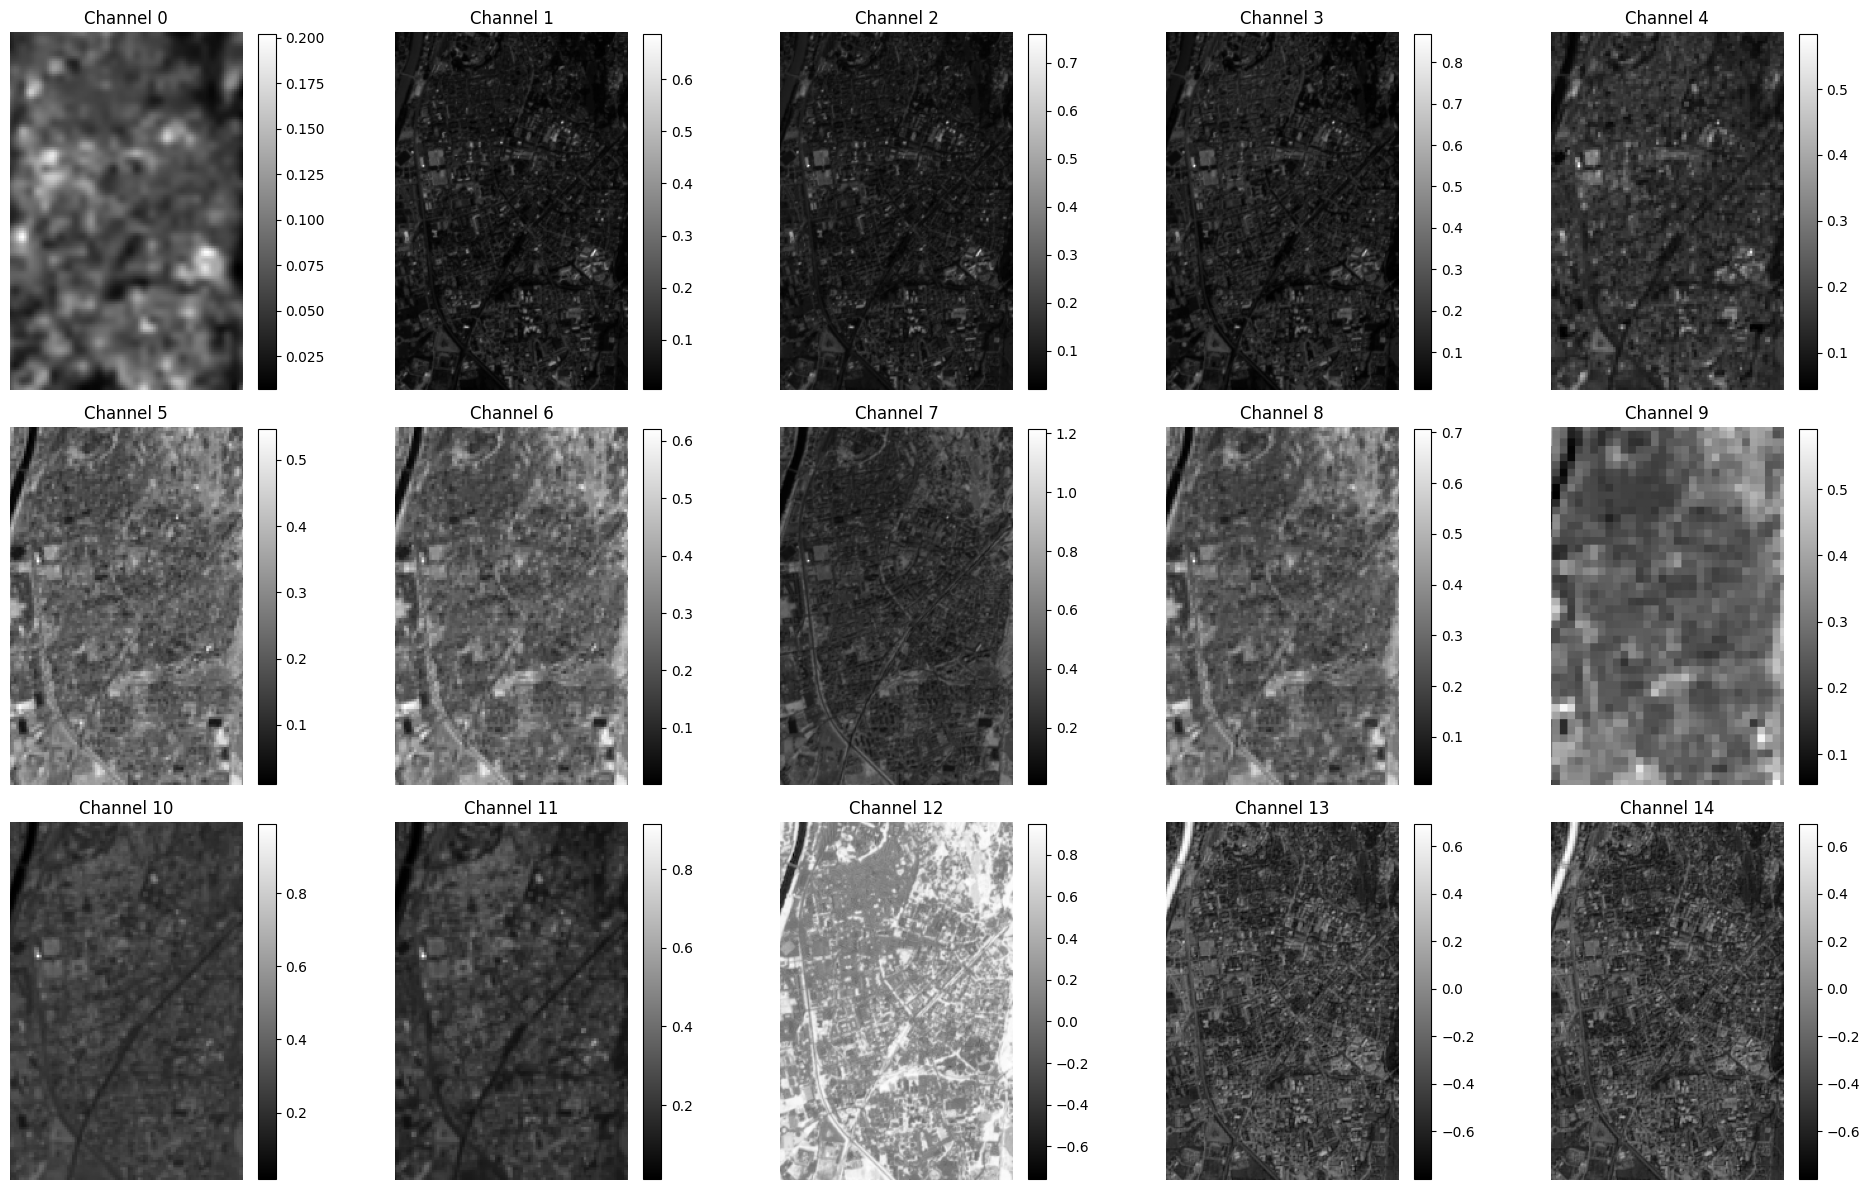


Checking for horizontal artifacts...
Channel 0: row_var=0.00, col_var=0.00, ratio=1.02
Channel 1: row_var=0.00, col_var=0.00, ratio=1.00
Channel 2: row_var=0.00, col_var=0.00, ratio=1.00
Channel 3: row_var=0.00, col_var=0.00, ratio=1.02
Channel 4: row_var=0.00, col_var=0.00, ratio=1.00
Channel 5: row_var=0.00, col_var=0.00, ratio=0.97
Channel 6: row_var=0.01, col_var=0.01, ratio=1.01
Channel 7: row_var=0.01, col_var=0.01, ratio=1.01
Channel 8: row_var=0.01, col_var=0.01, ratio=1.01
Channel 9: row_var=0.00, col_var=0.00, ratio=1.03
Channel 10: row_var=0.00, col_var=0.00, ratio=1.00
Channel 11: row_var=0.00, col_var=0.00, ratio=1.06
Channel 12: row_var=0.06, col_var=0.06, ratio=1.06
Channel 13: row_var=0.03, col_var=0.02, ratio=1.06
Channel 14: row_var=0.03, col_var=0.02, ratio=1.06


In [5]:
import tifffile
import matplotlib.pyplot as plt
import numpy as np

# Load original image
img = tifffile.imread('../data/sentinel_tensor_10m.tiff')
print(f"Image shape: {img.shape}")
print(f"Data type: {img.dtype}")
print(f"Value range: [{img.min()}, {img.max()}]")

# Visualize all 15 channels
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i in range(15):
    im = axes[i].imshow(img[:,:,i], cmap='gray')
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('all_channels.png', dpi=150, bbox_inches='tight')
plt.show()

# Also check for horizontal patterns across channels
print("\nChecking for horizontal artifacts...")
for i in range(15):
    # Compute variance along rows (horizontal) vs columns (vertical)
    row_var = np.var(img[:,:,i], axis=1).mean()
    col_var = np.var(img[:,:,i], axis=0).mean()
    ratio = row_var / col_var if col_var > 0 else 0
    print(f"Channel {i}: row_var={row_var:.2f}, col_var={col_var:.2f}, ratio={ratio:.2f}")